# Attention analysis: relation-aware vs vanilla self-attention

Attention *lift* of a relation type = mean attention weight on pairs of that type × number of keys (1 = uniform). Computed by `scripts/run_attention_analysis.py` over Spider dev examples for the FULL (relation-aware) model and baseline B (vanilla transformer, identical architecture without relation embeddings).

In [1]:
%matplotlib inline
import sys, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display
pd.set_option("display.max_colwidth", 200)

In [2]:
lift = ROOT / "results/tables/attention_relation_lift.md"
display(Markdown(lift.read_text(encoding="utf-8")) if lift.exists() else Markdown("_run scripts/run_attention_analysis.py first_"))

### Attention lift by relation type (1 = uniform attention; head-averaged; our measurements)

| Relation | Meaning | rat L1 | rat last | vanilla L1 | vanilla last |
|---|---|---|---|---|---|
| qq_dist_0 | question -> itself | 1.44 | 1.87 | 2.59 | 1.04 |
| qq_dist_1 | question -> next token | 1.29 | 3.42 | 2.44 | 1.38 |
| qc_em | question -> exactly-matched column | 1.98 | 3.30 | 2.87 | 2.51 |
| qc_pm | question -> partially-matched column | 3.57 | 1.79 | 1.56 | 1.48 |
| qc_vem | question -> value-matched column | 0.53 | 0.90 | 0.76 | 2.12 |
| qc_default | question -> unlinked column | 0.94 | 0.29 | 0.56 | 0.83 |
| qt_em | question -> exactly-matched table | 2.32 | 4.03 | 1.11 | 1.27 |
| qt_default | question -> unlinked table | 0.89 | 1.63 | 0.40 | 1.25 |
| ct_primary_key | column -> its table (PK) | 4.05 | 2.85 | 0.44 | 1.85 |
| ct_belongs_to | column -> its table | 1.82 | 2.79 | 0.79 | 1.77 |
| ct_default | column -> other table | 2.06 | 1.05 | 0.69 | 1.46 |
| cc_fk_forward | column -> FK target column | 1.35 | 5.75 | 1.00 | 0.73 |
| cc_same_table | column -> same-table column | 1.86 | 0.81 | 0.71 | 0.90 |
| cc_default | column -> unrelated column | 0.50 | 0.65 | 0.72 | 0.74 |
| tt_fk_forward | table -> FK-linked table | 1.38 | 2.31 | 0.62 | 1.65 |
| tt_default | table -> unrelated table | 4.45 | 1.81 | 0.80 | 1.30 |


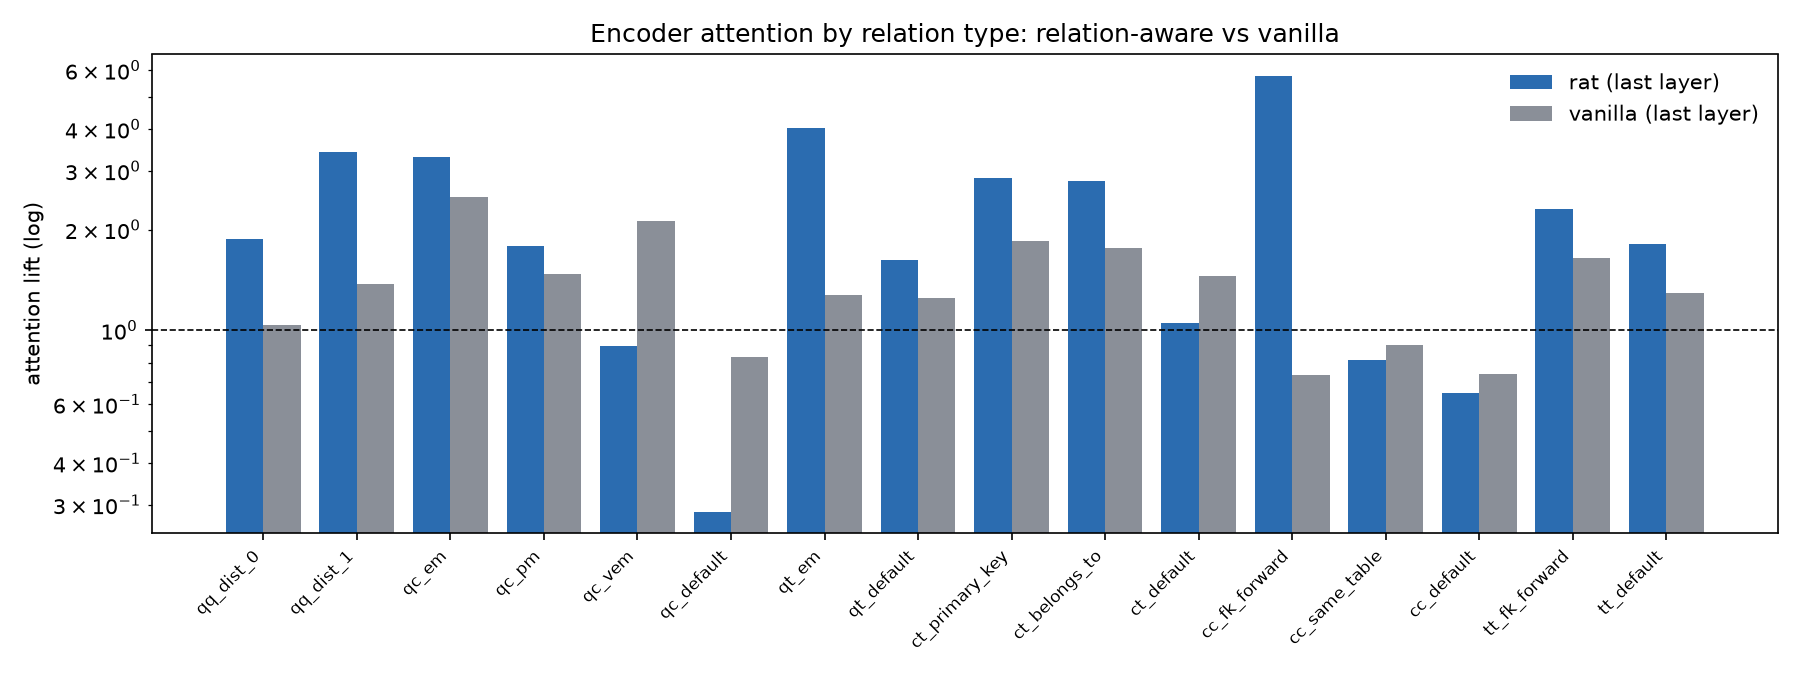

In [3]:
p = ROOT / "results/plots/attention_lift.png"
display(Image(filename=str(p))) if p.exists() else None

In [4]:
df = pd.read_csv(ROOT / "results/tables/attention_relation_lift.csv")
sel = ["qc_em", "qc_pm", "qc_vem", "qc_default", "qt_em", "qt_default", "ct_primary_key", "ct_belongs_to", "cc_fk_forward", "cc_default", "tt_fk_forward", "tt_default"]
piv = df[df.relation.isin(sel)].pivot_table(index=["relation"], columns=["model", "layer"], values="lift").round(2)
piv

model            rat                   vanilla                  
layer              1     2     3     4       1     2     3     4
relation                                                        
cc_default      0.50  0.72  0.67  0.65    0.72  1.13  0.73  0.74
cc_fk_forward   1.35  2.96  0.25  5.75    1.00  1.57  0.79  0.73
ct_belongs_to   1.82  4.89  1.45  2.79    0.79  1.63  1.81  1.77
ct_primary_key  4.05  6.55  0.26  2.85    0.44  1.10  2.04  1.85
qc_default      0.94  0.67  0.43  0.29    0.56  0.97  0.80  0.83
qc_em           1.98  9.54  5.78  3.30    2.87  2.33  0.64  2.51
qc_pm           3.57  2.41  2.67  1.79    1.56  1.71  0.65  1.48
qc_vem          0.53  5.36  8.51  0.90    0.76  1.37  0.55  2.12
qt_default      0.89  2.38  1.81  1.63    0.40  1.02  1.33  1.25
qt_em           2.32  9.82  7.19  4.03    1.11  2.67  1.72  1.27
tt_default      4.45  2.22  2.53  1.81    0.80  1.29  1.91  1.30
tt_fk_forward   1.38  3.24  2.51  2.31    0.62  1.10  1.85  1.65

## Per-layer trend of question → linked-column attention

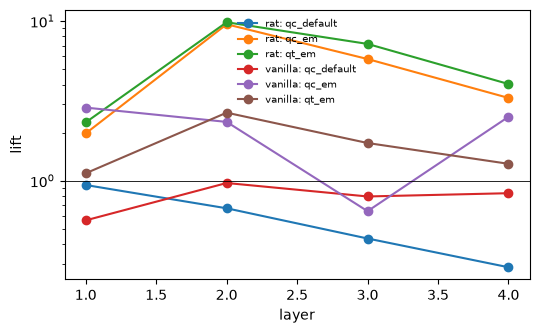

In [5]:
fig, ax = plt.subplots(figsize=(6, 3.5))
for (m, r), g in df[df.relation.isin(["qc_em", "qc_default", "qt_em"])].groupby(["model", "relation"]):
    ax.plot(g.layer, g.lift, "o-", label=f"{m}: {r}")
ax.set_yscale("log"); ax.set_xlabel("layer"); ax.set_ylabel("lift"); ax.axhline(1, color="k", lw=0.6); ax.legend(fontsize=7, frameon=False)

## Example heatmaps (last layer, head-averaged, question tokens × schema elements)

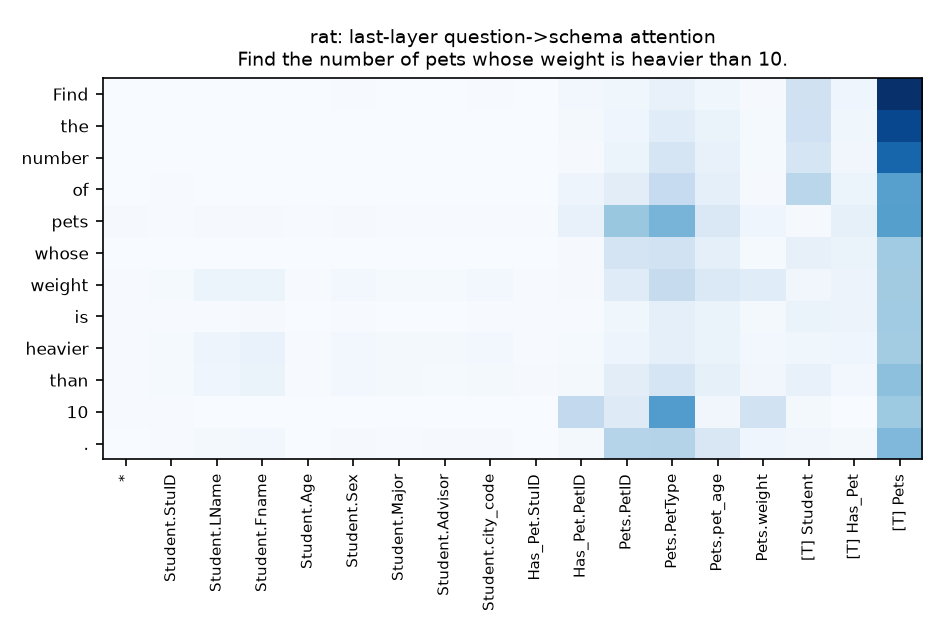

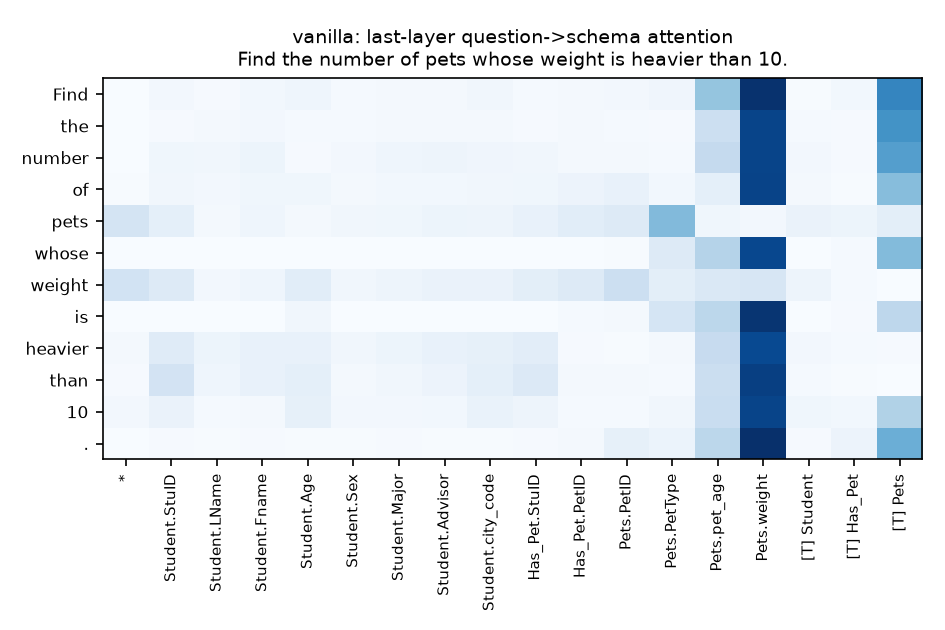

In [6]:
for name in ("rat", "vanilla"):
    p = ROOT / f"results/plots/attention_heatmap_{name}.png"
    if p.exists(): display(Image(filename=str(p)))